In [15]:
#load packages and read data (FILTERED RAW relative abundances (before CLR!) Shannon metrics expect proportions)
import pandas as pd
from skbio.diversity import alpha_diversity


abundance_filtered = pd.read_csv("data/processed/zeller2014_abundance_filtered.csv", index_col=0)
metadata = pd.read_csv("data/raw/zeller2014_metadata.csv", index_col=0)

In [14]:
# change working directory to its parent
import os


os.chdir("..")



In [16]:
# calculate alpha diversity metrics (Shannon, Simpson and Observed OTUs) for each sample
shannon = alpha_diversity('shannon', abundance_filtered.values, ids=abundance_filtered.index)
simpson = alpha_diversity('simpson', abundance_filtered.values, ids=abundance_filtered.index)
observed = alpha_diversity('observed_otus', abundance_filtered.values, ids=abundance_filtered.index)

alpha_df = pd.DataFrame({"shannon": shannon, "simpson": simpson, "observed": observed})
alpha_df = alpha_df.join(metadata["study_condition"])
alpha_df.groupby("study_condition")["shannon"].describe()

alpha_df.to_csv("data/processed/alpha_diversity.csv")



/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/skbio/util/_warning.py:42: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


In [17]:
#check the unique values in a column 
alpha_df.study_condition.unique()

<StringArray>
['control', 'CRC', 'adenoma']
Length: 3, dtype: str

In [25]:
# Run Kruskal-Wallis test to check for differences in alpha diversity between groups
from scipy.stats import kruskal

with open("results/alpha_diversity_kruskal-wallis.txt", "w") as f:
    for metric in ["shannon", "simpson", "observed"]:
        groups_data = [alpha_df.loc[alpha_df.study_condition == g, metric] for g in ["control", "CRC", "adenoma"]]
        stat, p = kruskal(*groups_data)
        f.write(f"{metric}: H={stat:.2f}, p={p:.4f}\n")
        print(f"{metric}: H={stat:.2f}, p={p:.4f}")



# if the p-value is significant, perform pairwise comparisons using Mann-Whitney U test. Apply Bonferroni correction for multiple comparisons.

shannon: H=1.31, p=0.5199
simpson: H=2.80, p=0.2472
observed: H=0.38, p=0.8266


In [19]:
#Test alpha diversity between each pair of groups using Mann-Whitney U test
from scipy.stats import mannwhitneyu

crc = alpha_df.loc[alpha_df.study_condition == "CRC", "shannon"]
control = alpha_df.loc[alpha_df.study_condition == "control", "shannon"]
adenoma = alpha_df.loc[alpha_df.study_condition == "adenoma", "shannon"]

comparisons = {
    "CRC vs control": (crc, control),
    "CRC vs adenoma": (crc, adenoma),
    "control vs adenoma": (control, adenoma),
}

results = {}
for label, (group1, group2) in comparisons.items():
    stat, p_value = mannwhitneyu(group1, group2)
    results[label] = (stat, p_value)
    print(f"Mann-Whitney U ({label}): stat={stat:.2f}, p={p_value:.4f}")

with open("results/alpha_diversity_mannwhitneyu.txt", "w") as f:
    for label, (stat, p_value) in results.items():
        f.write(f"Mann-Whitney U ({label}): stat={stat:.2f}, p={p_value:.4f}\n")

Mann-Whitney U (CRC vs control): stat=1493.00, p=0.4847
Mann-Whitney U (CRC vs adenoma): stat=1166.00, p=0.6940
Mann-Whitney U (control vs adenoma): stat=1450.00, p=0.2581


In [20]:
# calculate beta diversity metrics (Bray-Curtis and Aitchison)
from skbio.diversity import beta_diversity
from skbio import DistanceMatrix
from scipy.spatial.distance import pdist, squareform

bray_curtis = beta_diversity("braycurtis", abundance_filtered.values, ids=abundance_filtered.index)

abundance_clr = pd.read_csv("data/processed/zeller2014_abundance_clr.csv", index_col=0)
aitchison = DistanceMatrix(
    squareform(pdist(abundance_clr.values, metric="euclidean")),
    ids=abundance_clr.index
)

/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:222: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:359: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.17210994299188312 whereas the largest positive one is 4.3263932542386945.
  warn(


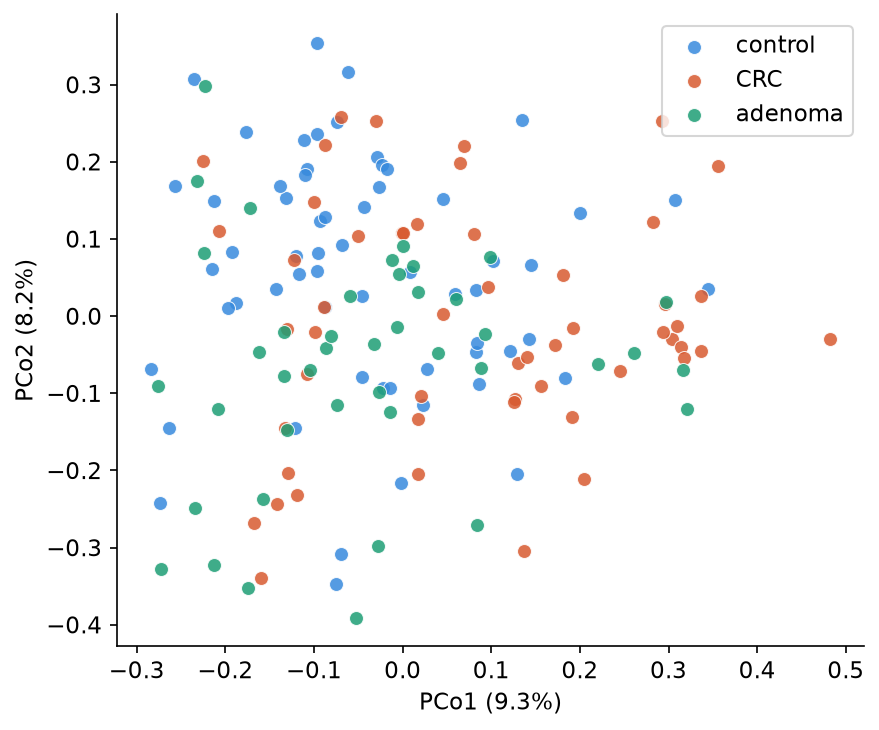

In [21]:
# PCoA and plot 
from skbio.stats.ordination import pcoa
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
palette = {"control": "#378ADD", "CRC": "#D85A30", "adenoma": "#1D9E75"}  # colorblind-safe

pcoa_results = pcoa(bray_curtis)
coords = pcoa_results.samples[["PC1", "PC2"]]
labels = metadata.loc[coords.index, "study_condition"]

fig, ax = plt.subplots(figsize=(6, 5))

for label in labels.unique():

    mask = labels == label

    sns.scatterplot(
        x=coords.loc[mask, "PC1"],
        y=coords.loc[mask, "PC2"],
        label=label,
        color=palette[label],
        s=45,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
        ax=ax
    )

ax.set_xlabel(f"PCo1 ({100*pcoa_results.proportion_explained['PC1']:.1f}%)")
ax.set_ylabel(f"PCo2 ({100*pcoa_results.proportion_explained['PC2']:.1f}%)")

ax.legend()
plt.tight_layout()
plt.savefig("figures/pcoa_braycurtis.png", dpi=300)

                                                   

In [22]:
# PERMANOVA test to assess the significance of differences in beta diversity between groups:
from skbio.stats.distance import permanova

# permanova with Bray-Curtis distance
groups = metadata["study_condition"].reindex(bray_curtis.ids)
result = permanova(bray_curtis, groups, permutations=999)
print(result)

with open("results/permanova_braycurtis.txt", "w") as f:
    f.write(str(result))

# permanova with Aitchison distance
groups = metadata["study_condition"].reindex(aitchison.ids)
result = permanova(aitchison, groups, permutations=999)
print(result)

with open("results/permanova_aitchison.txt", "w") as f:
    f.write(str(result))


method name               PERMANOVA
test statistic name        pseudo-F
sample size                     156
number of groups                  3
test statistic             2.719986
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     156
number of groups                  3
test statistic             1.958761
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


/tmp/ipykernel_63558/505566155.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=alpha_df, x="study_condition", y="shannon", palette=palette, ax=ax)
/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/seaborn/categorical.py:700: MatplotlibDeprec

/tmp/ipykernel_63558/505566155.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=alpha_df, x="study_condition", y="simpson", palette=palette, ax=ax)
/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/marcela/miniconda3/envs/microbiome/lib/python3.11/site-packages/seaborn/categorical.py:700: MatplotlibDeprec

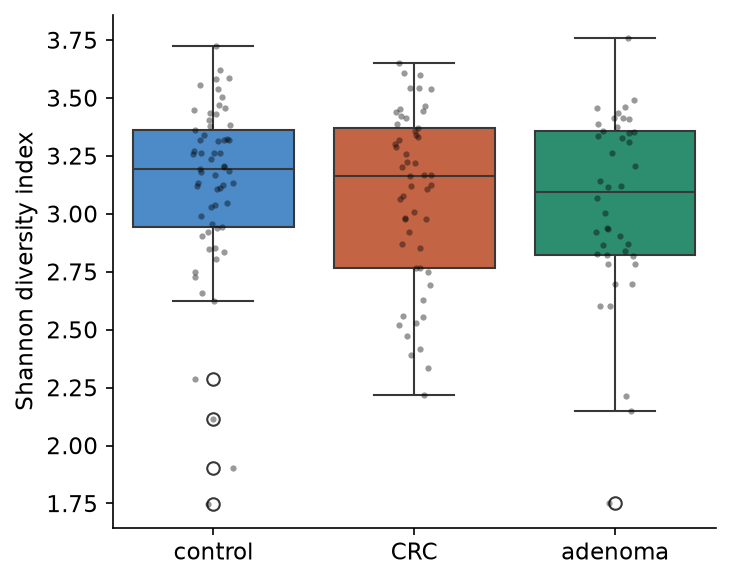

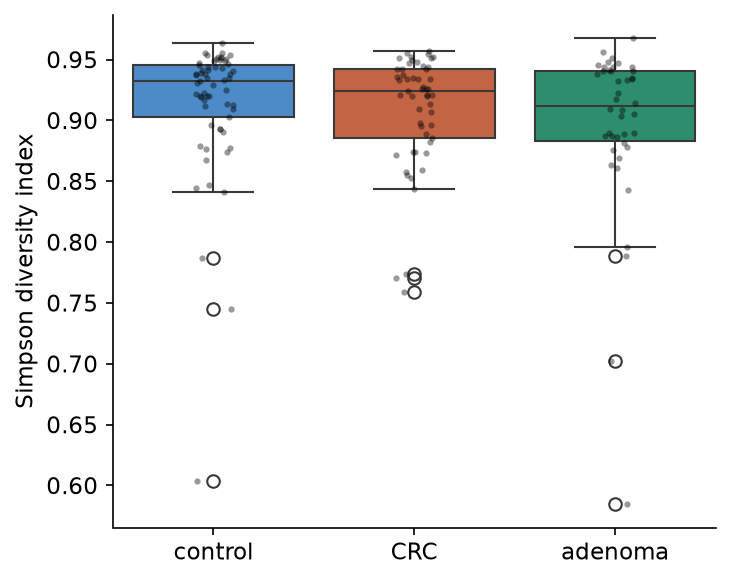

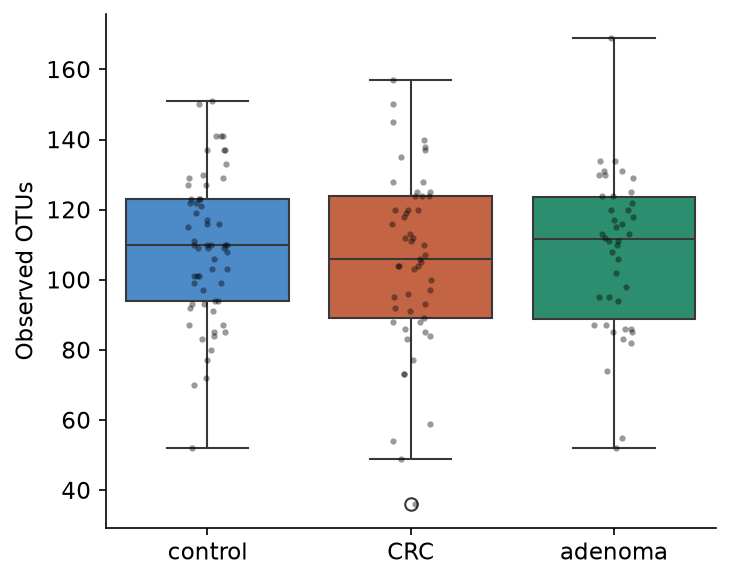

In [23]:
# plot alpha diversity
import matplotlib.pyplot as plt
import seaborn as sns

# shannon 
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
palette = {"control": "#378ADD", "CRC": "#D85A30", "adenoma": "#1D9E75"}  # colorblind-safe

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=alpha_df, x="study_condition", y="shannon", palette=palette, ax=ax)
sns.stripplot(data=alpha_df, x="study_condition", y="shannon", color="black", alpha=0.4, size=3, ax=ax)
ax.set_ylabel("Shannon diversity index")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figures/alpha_diversity_boxplot_shannon.png", dpi=300)


# simpson
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
palette = {"control": "#378ADD", "CRC": "#D85A30", "adenoma": "#1D9E75"}  # colorblind-safe

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=alpha_df, x="study_condition", y="simpson", palette=palette, ax=ax)
sns.stripplot(data=alpha_df, x="study_condition", y="simpson", color="black", alpha=0.4, size=3, ax=ax)
ax.set_ylabel("Simpson diversity index")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figures/alpha_diversity_boxplot_simpson.png", dpi=300)


# observed OTUS
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
palette = {"control": "#378ADD", "CRC": "#D85A30", "adenoma": "#1D9E75"}  # colorblind-safe

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=alpha_df, x="study_condition", y="observed", palette=palette, ax=ax)
sns.stripplot(data=alpha_df, x="study_condition", y="observed", color="black", alpha=0.4, size=3, ax=ax)
ax.set_ylabel("Observed OTUs")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figures/alpha_diversity_boxplot_observed.png", dpi=300)